# Модуль 12. Среда, награда, политика

Ноутбук к [модулю 12](https://drobyshevdev.github.io/lemma/modules/12-environment-reward-policy/).

Марковский процесс принятия решений руками: gridworld, value iteration, политика как тень ценности, и закон эффекта Торндайка на числах. Только `numpy` и `matplotlib`, считается мгновенно.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Gridworld как MDP

Четыре строки, четыре столбца. Цель `+1` справа сверху, яма `-1` под ней, две стены. За каждый шаг плата `-0.03`, чтобы агент не бродил зря. Переход детерминированный: упёрся в стену или край — остался на месте.

In [2]:
R, C = 4, 5
GOAL, PIT = (0, 4), (1, 4)
WALLS = {(1, 1), (2, 3)}
STEP = -0.03
ACTS = {"\u2191": (-1, 0), "\u2193": (1, 0), "\u2190": (0, -1), "\u2192": (0, 1)}

def terminal(s): return s == GOAL or s == PIT

def nxt(r, c, dr, dc):
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= R or nc < 0 or nc >= C or (nr, nc) in WALLS:
        return (r, c)                      # упёрся -- остался
    return (nr, nc)

print("состояний:", R * C - len(WALLS), " действий:", len(ACTS))

состояний: 18  действий: 4


## 2. Value iteration

Уравнение Беллмана как правило пересчёта: ценность клетки — плата за шаг плюс дисконтированная лучшая ценность соседа. Гоняем до сходимости.

In [3]:
def value_iteration(gamma, iters=200, tol=1e-9):
    V = np.zeros((R, C)); V[GOAL], V[PIT] = 1.0, -1.0
    deltas = []
    for _ in range(iters):
        nV = V.copy(); d = 0.0
        for r in range(R):
            for c in range(C):
                if (r, c) in WALLS or terminal((r, c)):
                    continue
                best = max(V[nxt(r, c, dr, dc)] for dr, dc in ACTS.values())
                nV[r, c] = STEP + gamma * best
                d = max(d, abs(nV[r, c] - V[r, c]))
        V = nV; deltas.append(d)
        if d < tol:
            break
    return V, deltas

def greedy_policy(V):
    P = {}
    for r in range(R):
        for c in range(C):
            if (r, c) in WALLS or terminal((r, c)):
                continue
            P[(r, c)] = max(ACTS, key=lambda a: V[nxt(r, c, *ACTS[a])])
    return P

V, deltas = value_iteration(0.9)
P = greedy_policy(V)
print("проходов до сходимости:", len(deltas))
print("ценность старта (3,0): %.3f" % V[3, 0])

проходов до сходимости: 9
ценность старта (3,0): 0.322


Рисуем карту ценности и стрелки политики. Стрелка — не отдельный объект: она просто указывает на соседа с наибольшей ценностью.

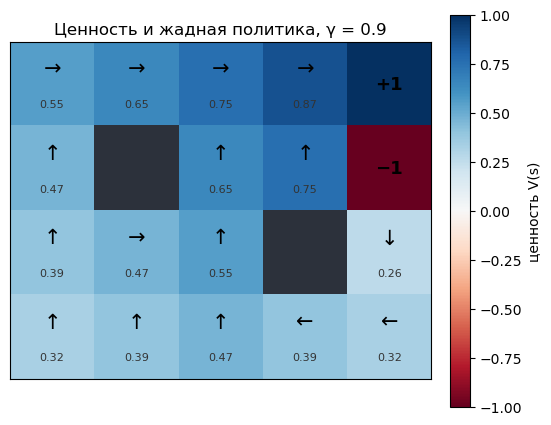

In [4]:
def draw(V, P, title):
    Vm = V.copy().astype(float)
    for w in WALLS:
        Vm[w] = np.nan
    fig, ax = plt.subplots(figsize=(5.6, 4.4))
    cmap = plt.cm.RdBu.copy(); cmap.set_bad("#2c313b")
    im = ax.imshow(Vm, cmap=cmap, vmin=-1, vmax=1)
    for r in range(R):
        for c in range(C):
            if (r, c) in WALLS:
                continue
            if (r, c) == GOAL:
                ax.text(c, r, "+1", ha="center", va="center", fontsize=13, weight="bold")
            elif (r, c) == PIT:
                ax.text(c, r, "\u22121", ha="center", va="center", fontsize=13, weight="bold")
            else:
                ax.text(c, r - 0.18, P[(r, c)], ha="center", va="center", fontsize=15)
                ax.text(c, r + 0.24, f"{V[r, c]:.2f}", ha="center", va="center", fontsize=8, color="#333")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ценность V(s)")
    plt.tight_layout(); plt.show()

draw(V, P, "Ценность и жадная политика, \u03b3 = 0.9")

Ценность растекается от цели, политика складывается в маршрут в обход ямы и стен.

**Сломать.** Поставьте `STEP = 0` и перерисуйте: без платы за шаг агенту всё равно, коротким путём идти или петлять. Поставьте `STEP = -0.2` — маршрут станет резко коротким, а дальние клетки могут предпочесть яму быстрому концу.

## 3. Как \u03b3 меняет политику

Дисконт — это дальновидность одним числом. При малом \u03b3 дальние клетки цель не видят: будущее обесценено так, что плата за шаг перевешивает далёкую награду.

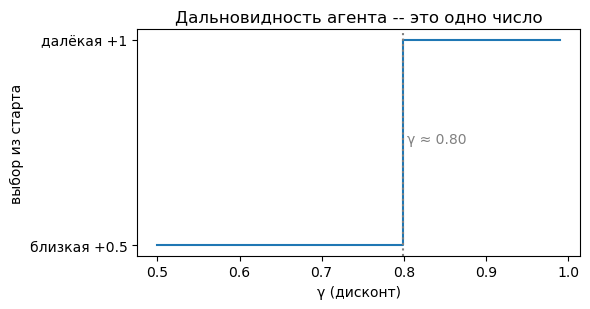

порог: γ ≈ 0.8  (теория: 0.5**(1/3) = 0.79 )


In [5]:
# коридор из 6 клеток: маленькая награда +0.5 слева (1 шаг), большая +1 справа (4 шага)
n = 6; NEAR, FAR, START = 0, 5, 1
r_near, r_far = 0.5, 1.0

def corridor_goes_far(gamma):
    V = np.zeros(n); V[NEAR], V[FAR] = r_near, r_far
    for _ in range(500):
        nV = V.copy()
        for s in range(1, n - 1):
            nV[s] = gamma * max(V[s - 1], V[s + 1])     # шаг без платы, только дисконт
        V = nV
    return int(V[START + 1] > V[START - 1])             # 1 = вправо, к далёкой +1

gammas = np.linspace(0.5, 0.99, 60)
goes_far = [corridor_goes_far(g) for g in gammas]
thr = float(gammas[np.argmax(goes_far)]) if any(goes_far) else None

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.step(gammas, goes_far, where="post")
if thr is not None:
    ax.axvline(thr, ls=":", color="gray"); ax.text(thr + 0.005, 0.5, f"γ ≈ {thr:.2f}", color="gray")
ax.set_xlabel("γ (дисконт)"); ax.set_ylabel("выбор из старта")
ax.set_yticks([0, 1]); ax.set_yticklabels(["близкая +0.5", "далёкая +1"])
ax.set_title("Дальновидность агента -- это одно число")
plt.tight_layout(); plt.show()
print("порог: γ ≈", None if thr is None else round(thr, 2),
      " (теория: 0.5**(1/3) =", round(0.5 ** (1 / 3), 2), ")")

Ниже порога агент хватает близкую награду, выше — терпит ради далёкой большей. Порог γ ≈ 0.79 совпадает с расчётом: далёкая награда в четырёх шагах против близкой в одном сравниваются при γ³ = 0.5. Заданная близорукость, а не свойство мира.

**Сломать.** Отодвиньте большую награду дальше (`FAR = 7`, `n = 8`) — порог поднимется: чем дальше приз, тем дальновиднее нужен агент.

## 4. Закон эффекта Торндайка

Одно состояние, два действия. Ценность действия обновляется по награде: `Q += \u03b1 (r - Q)`. Никакой модели среды, никакого планирования — только «действие, за которым следует награда, закрепляется». Поведение должно само сдвинуться к вознаграждаемому действию.

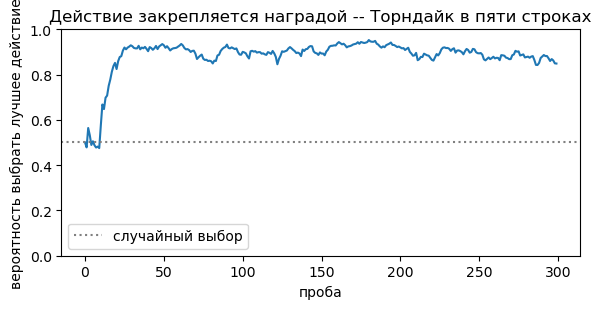

итоговые ценности действий: [0.89 0.39]  предпочтение лучшего: 0.85


In [6]:
mu = [1.0, 0.3]          # истинная средняя награда: действие 0 лучше
Q = np.zeros(2)
alpha, temp = 0.1, 0.3
pref = []
for t in range(300):
    p = np.exp(Q / temp); p /= p.sum()          # выбор мягкий, по ценности
    a = rng.choice(2, p=p)
    r = mu[a] + rng.normal(0, 0.3)              # шумная награда
    Q[a] += alpha * (r - Q[a])                  # закон эффекта
    pref.append(p[0])

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(pref)
ax.axhline(0.5, ls=":", color="gray", label="случайный выбор")
ax.set_xlabel("проба"); ax.set_ylabel("вероятность выбрать лучшее действие")
ax.set_ylim(0, 1); ax.set_title("Действие закрепляется наградой -- Торндайк в пяти строках")
ax.legend(); plt.tight_layout(); plt.show()
print("итоговые ценности действий:", Q.round(2), " предпочтение лучшего: %.2f" % pref[-1])

Кошка Торндайка «быстрее добирается до рычага» — это и есть рост `Q` вознаграждаемого действия и сдвиг выбора к нему. Психология назвала это законом эффекта, математика — обновлением ценности. Модель одна.

**Сломать.** Сделайте награды почти равными (`mu = [0.6, 0.5]`) — предпочтение будет расти медленно и шумно: близкие ценности при шумной награде трудно различить, ровно как в модуле 1.

## 5. Почему value iteration сходится

Оператор Беллмана — сжатие: каждый проход уменьшает расстояние до решения в \u03b3 раз. Поэтому изменение между проходами падает геометрически.

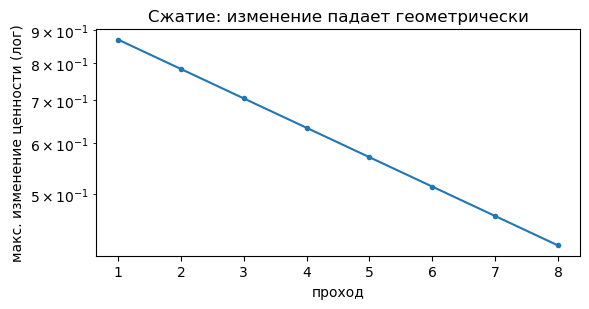

отношение соседних изменений: 0.90 = γ (граница сжатия)


In [7]:
_, deltas = value_iteration(0.9)
pos = [d for d in deltas if d > 0]                 # последний проход доводит до нуля точно
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(range(1, len(pos) + 1), pos, "o-", ms=3)
ax.set_xlabel("проход"); ax.set_ylabel("макс. изменение ценности (лог)")
ax.set_title("Сжатие: изменение падает геометрически")
plt.tight_layout(); plt.show()
ratios = [pos[i + 1] / pos[i] for i in range(len(pos) - 1)]
print("отношение соседних изменений: %.2f = γ (граница сжатия)" % np.mean(ratios))

Прямая на логарифмической оси — это геометрическое падение, а его знаменатель равен \u03b3. Отсюда и гарантия: сколько бы ни было состояний, value iteration сходится, и тем быстрее, чем меньше дисконт.

## Что дальше

Здесь ценность считалась при известной модели среды: мы знали переходы и награды заранее. [Модуль 13](https://drobyshevdev.github.io/lemma/programme/) снимает это допущение — ценность учат по одному переходу за раз, без модели. Центральная величина там — ошибка предсказания награды, и она же окажется сигналом дофаминовых нейронов.